# Week 3: ViT
(see summary at bottom and notes throughout)

Mounting drive, setting up libraries (see week 2 for library explanations)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive
A


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from tqdm import tqdm
import os, copy, json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


**data set up**

Similar to last week with the transform set ups. We have the train_transform to tensor, normalize, and augment the frames to make the model catch features more robustly. Val_transform does the samething like last week where it tensors and normalizes but does not augment. Then we load into the ImageFolder to create real v fake, and train val and test subfolders.


In [5]:
data_dir = '/content/frames/' #where the frames tempo live while google drive is mounted
#the train transform will augment the frames (horizontalflip, rotation, jitter)
#then tensors and normalizes
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
#no augmentation just tensors and normalizes
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
#creating the proper image folders for train val and test
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)
#just checking again because had a lil moment with errors earlier
print(f"Classes: {train_dataset.classes}")
print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Train: 195786, Val: 34636, Test: 20055


**Training set up same thing as last week basically**

Like last week this is to address the balance issue with the data. It makes weights to be applied to that issue to have it pay more attention to the real class.
Something that is different here is that because the model is bigger the num workers is upped to 4 instead of 2 for EfficientNet. The structure of the loaders otherwise is the same as last week 2.

**The model**

This time we are using the ViT-base/16 model. The difference between Vit and EN is that EN was a convolutional neural network and Vit is a transformer. This is very different architecture to work with as the transformer is set to work with ision instead of NLP. This allows its to capture the relationships that fake images share or even real ones lack more effectively. But comes with the caveat of needing more data and power.

**Learning rate, warmup, and cosine decay**

Nearly the same thing as last week with a few differences: AdamW instead of Adam, the learning rate, and the sequential learning rate scheduler. The easy one is the learning rate is init at .000001 now. AdamW is used as it separates the L2 regularization (weight decay penalty) from the learning rate update making it a distinct penalty slapped onto the weights. This will make the weights more effective and hopefully leads to better generalization here. The slrs combines the warm up epochs where the learning rate starts low (see above) then will go to full base learning throughout the first two epochs. This will make trianing in the beginning less jumpy and more stable, and prevent the gradient from having huge updates that will add to the instability. The cosine decay is a part of the slrs as it is how the learning rate updates through the remaining epochs. In essence it starts from the peak learning rate reached after the second epoch then will gradually decay down over the remaining epochs. This helps for the model to take larger steps then transition to more precise steps at the end of training.

In [6]:
train_targets = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(train_targets)
print(f"Class counts - fake: {class_counts[0]}, real: {class_counts[1]}")
#inverse of the ratio of class inbalance to make real class the vip
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

#batch size constant
BATCH_SIZE = 64
#loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Batches per epoch - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Class counts - fake: 170930, real: 24856
Batches per epoch - Train: 3060, Val: 542, Test: 314


In [7]:
# Load pretrained ViT-Base/16 (ImageNet-21k weights)
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Thaw the classification head
for param in model.head.parameters():
    param.requires_grad = True

# Thaw the last 3 transformer blocks
for param in model.blocks[-3:].parameters():
    param.requires_grad = True

# Thaw layer norm before head
for param in model.norm.parameters():
    param.requires_grad = True

model = model.to(device)
#seeing the number of trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params: 21,266,690 / 85,800,194 (24.8%)


In [8]:
# Lower learning rate for ViT bc transformers are sensitive
if class_counts[1] == 0:
    # Handles the case where there are no 'real' samples, or adjust weights as appropriate
    # For now tho, setting a default or raising an error would be options
    # Ex,  assume a default of 1.0 if it's 0 to prevent error
    # but a more robust solution might depend on the dataset characteristics
    print("Warning: class_counts[1] is zero. Adjusting weight for 'real' class to 1.0.")
    weight_tensor = torch.tensor([1.0, 1.0], dtype=torch.float).to(device)
else:
    weight_tensor = torch.tensor([1.0, class_counts[0]/class_counts[1]], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)
print(f"Loss weights - fake: {weight_tensor[0]:.2f}, real: {weight_tensor[1]:.2f}")

# Warmup + cosine decay
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=0.01
)
#total epochs and warmup epochs
NUM_EPOCHS = 15
warmup_epochs = 2
#learning schedule
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - warmup_epochs, eta_min=1e-6)
scheduler_warmup = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs])

Loss weights - fake: 1.00, real: 6.88


# Its training time!

**training set up**

The GradScaler is important to speed up the training and reduce the memory usage being used here as this an intensive training process on an intensive model. It is making the whole training a Automatic Mixed Precision (AMP) training. It will autocast some operations in float16 and others in float32, half and full precision. This will affect the accuracy a tad in backpropogation in the scaling of gradients.

Then same thing as last week mostly. Differences here is the scaler having interaction in the backpropogation, it scales the loss before heading to backward() to prevent the gradients becoming too small for float16. Another difference is clip_grad_norm_() which clips the magnitude of the gradients to a max value of 1.0 which helps stabilize the training. Then we have more scaler activity in scaler.step which just accounts for the scaling by GradScaler. Update is interacted with by its internal scale factor depending on the gradients under or over flowing.

**training loop**

The actual training part. Which also not different from last week so no further discussion here.

In [10]:
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer) # Unscale gradients before clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc, all_probs, all_labels

/tmp/ipykernel_703/1961376219.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [11]:
best_val_auc = 0.0
best_model_state = None
patience_counter = 0
PATIENCE = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best model (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> Early stopping at epoch {epoch+1}")
            break

# Save best model
model.load_state_dict(best_model_state)
save_path = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
os.makedirs(save_path, exist_ok=True)
torch.save(best_model_state, os.path.join(save_path, 'vit_base16_best.pth'))
print(f"\nBest model saved with Val AUC: {best_val_auc:.4f}")

Training:   0%|          | 0/3060 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/542 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


Epoch 1/15 | Train Loss: 0.2420 Acc: 0.6951 | Val Loss: 0.8720 Acc: 0.6205 AUC: 0.6895 | LR: 0.000017
  -> New best model (AUC: 0.6895)


Training:   0%|          | 0/3060 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/542 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


Epoch 2/15 | Train Loss: 0.1385 Acc: 0.8582 | Val Loss: 0.6474 Acc: 0.7937 AUC: 0.7876 | LR: 0.000030
  -> New best model (AUC: 0.7876)


Training:   0%|          | 0/3060 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/542 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


...

Epoch 10/15 | Train Loss: 0.0267 Acc: 0.9828 | Val Loss: 1.1290 Acc: 0.8720 AUC: 0.7810 | LR: 0.000010


Training:   0%|          | 0/3060 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/542 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


Epoch 11/15 | Train Loss: 0.0233 Acc: 0.9858 | Val Loss: 1.1724 Acc: 0.8847 AUC: 0.7728 | LR: 0.000007


Training:   0%|          | 0/3060 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/542 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


Epoch 12/15 | Train Loss: 0.0194 Acc: 0.9878 | Val Loss: 1.3051 Acc: 0.8778 AUC: 0.7500 | LR: 0.000005
  -> Early stopping at epoch 12

Best model saved with Val AUC: 0.8015


# Plots and Saving

plot 1: 3 subplots that focus on: loss over epoch in train and val; accuracy of training and val over epoch, val auc ros over epochs.

plot 2: prints the calculated test loss, accuracy, and auc roc score. Also prints a classification report that has precision, recall, and the f1 score for real and fake. Finally a confusion matrix display.

**Saving**

This saves the training history and plots to the checkpoints folder.



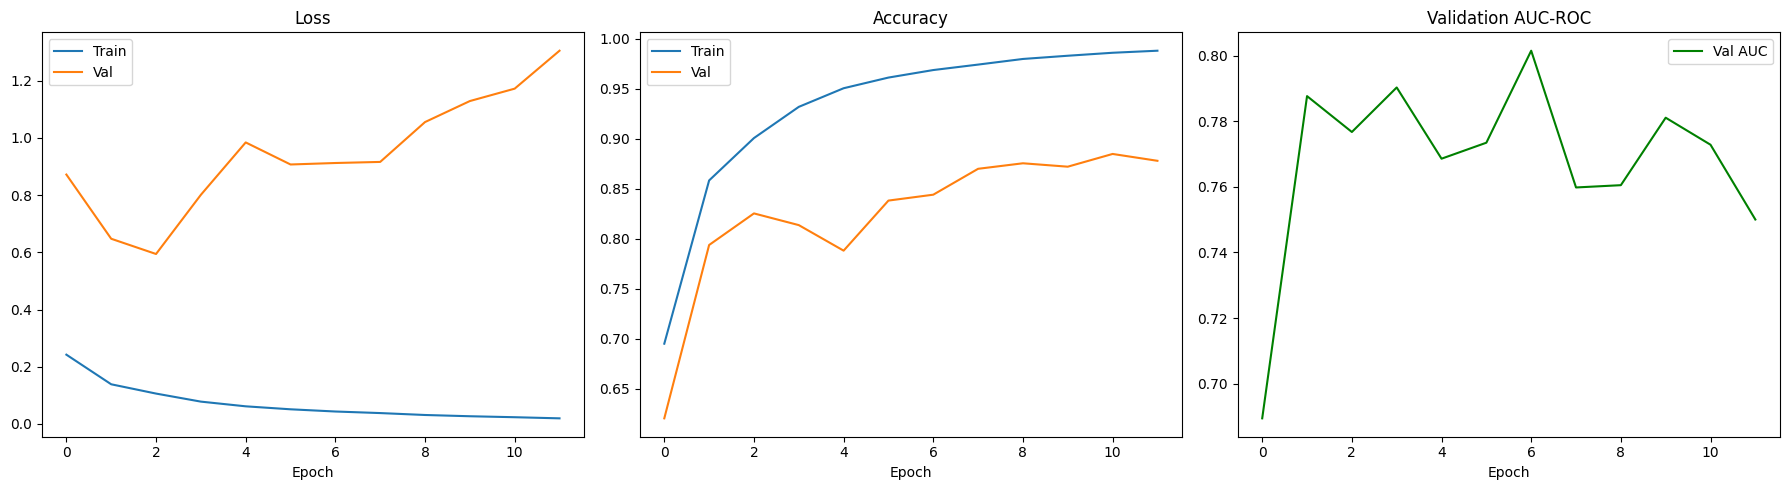

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['val_auc'], label='Val AUC', color='green')
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

Evaluating:   0%|          | 0/314 [00:00<?, ?it/s]/tmp/ipykernel_703/1961376219.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use autocast for evaluation too, for consistency and potential speedup


Test Loss: 1.6927
Test Accuracy: 0.7577
Test AUC-ROC: 0.8137

Classification Report:
              precision    recall  f1-score   support

        fake       0.79      0.86      0.82     12939
        real       0.69      0.58      0.63      7116

    accuracy                           0.76     20055
   macro avg       0.74      0.72      0.72     20055
weighted avg       0.75      0.76      0.75     20055



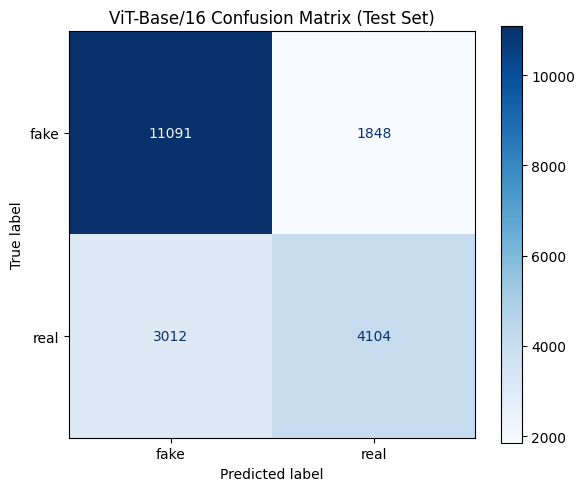

In [13]:
test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

test_preds = [1 if p > 0.5 else 0 for p in test_probs]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=train_dataset.classes))

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('ViT-Base/16 Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

Checkpoints:
  efficientnet_b0_best.pth
  vit_base16_best.pth

Training history saved.
Learning curves saved.
Confusion matrix saved.

All Week 3 artifacts saved to Drive. Safe to start a new notebook.


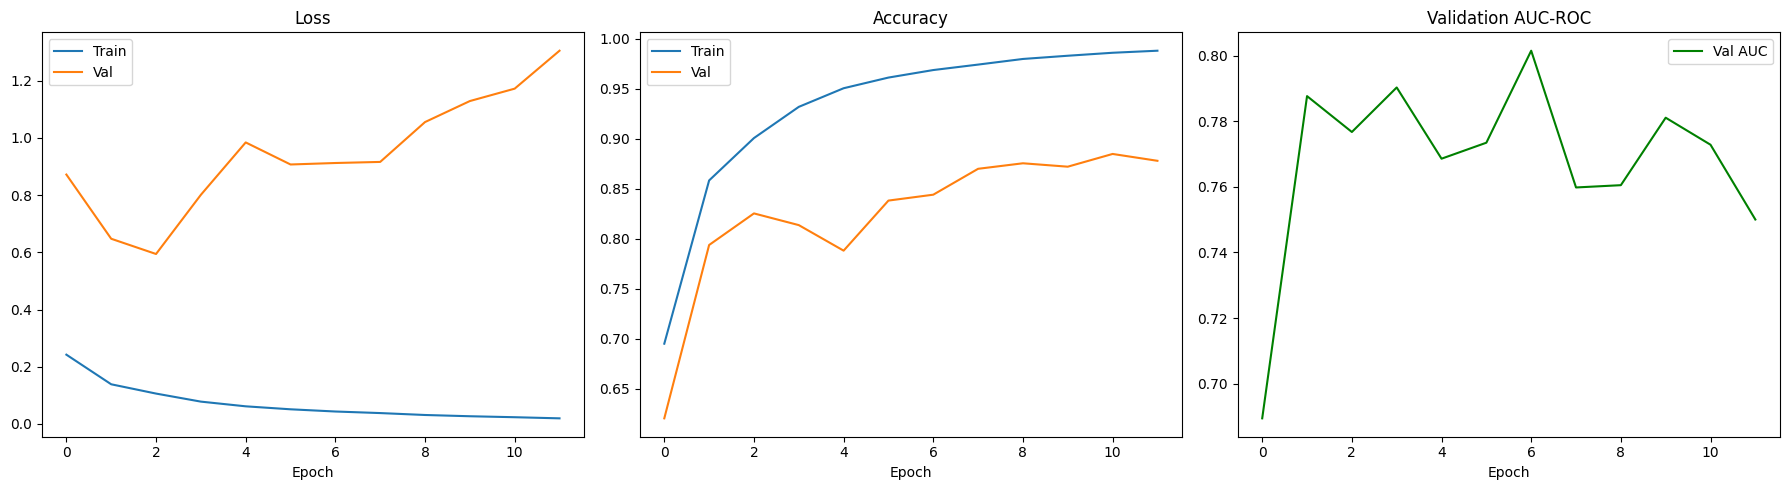

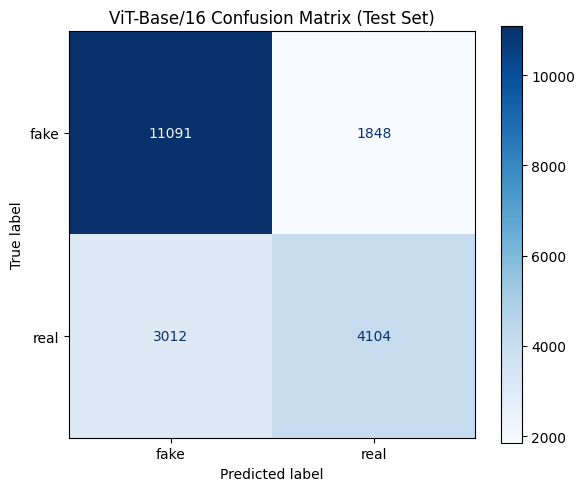

In [15]:

# Create results folder on Drive
os.makedirs('/content/drive/MyDrive/deepfake_capstone/results/', exist_ok=True)

# Verify checkpoints exist
print("Checkpoints:")
for f in os.listdir('/content/drive/MyDrive/deepfake_capstone/checkpoints/'):
    print(f"  {f}")

# Save training history
history_save = {k: [float(v) for v in vals] for k, vals in history.items()}
with open('/content/drive/MyDrive/deepfake_capstone/checkpoints/vit_v1_history.json', 'w') as f:
    json.dump(history_save, f)
print("\nTraining history saved.")

# Save learning curves
fig_curves, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[2].plot(history['val_auc'], label='Val AUC', color='green')
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
plt.tight_layout()
fig_curves.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v1_learning_curves.png', dpi=150)
print("Learning curves saved.")

# Save confusion matrix
fig_cm, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('ViT-Base/16 Confusion Matrix (Test Set)')
plt.tight_layout()
fig_cm.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v1_confusion_matrix.png', dpi=150)
print("Confusion matrix saved.")

print("\nAll Week 3 artifacts saved to Drive. Safe to start a new notebook.")

# Summary
Fine tuned  ViT-Base/16 (ImageNet-21k pretrained) on the same data splits as the baseline(EfficientNet). Froze all layers except the classifier head, layer norm, and last 3 transformer blocks. Used AdamW with weight decay (0.01), a lower learning rate (3e-5) than the CNN, warmup + cosine decay scheduling, and gradient clipping at 1.0. Added early stopping with patience of 5.

**Results**: 75.77% test accuracy, 0.8137 AUC-ROC. Beat the baseline on every metric. Real recall improved from 52% to 58%, real F1 from 0.58 to 0.63. AUC crossed the 0.80 target. Best model at epoch 7 with val AUC of 0.8015. Still overfitting, the train accuracy hit 98% while val plateaued around 84%, but the gap was more controlled than EfficientNet thanks to the nifty cosine decay schedule.

**Takeaways**: The ViT's self attention mechanism outperforms the CNN at distinguishing real from fake faces particularly improving the weak point of real image detection. The overfitting and remaining real recall weakness is going to be the focal point of the tuning experiments in Week 4.